In [1]:
%run neural_simulation_functions.ipynb

Parameters.

In [3]:
num_neurons = 2
rate = 10 
time = 1000
num_samples = 100 # change to 100 to show Alex next time, but plot the first five trajectories or random five 
t0 = 200

In [4]:
# Simulation control parameters

# Network parameters
N_E = 1000
gamma = 0.25                    # ratio of inhibitory to excitatory neurons
N_I = round(gamma * N_E)
N = N_E + N_I
epsilon = 0.5                   # Sparsity of connections.  changed from 0.1, 0.2 was fine...
C_E = epsilon * N_E             # number of excitatory connections per neuron
C_ext = C_E                     # external connections per neuron


# Neuron parameters
tau = 20  * ms                  # Membrane time constant. previously 20, tried 50 it was weird, larger numbers more spikes, smaller numbers less spikes
                                # Higher Tau means slower decay, more spikes.
                                # Lower Tau means faster decay, fewer spikes
theta = 20  * mV                # spike threshold voltage, neuron fires when hitting this value
V_r = 10  * mV                  # reset potential, voltage neuron goes back to after firing
tau_rp = 2  * ms                # refractory period (neuron needs to wait some time before spiking again)

# Synapse parameters
J = 0.1 * mV                    # Synaptic strength # Previously 0.1 * mV, previouysly 0.075, 0.2 was too varied need to be more consistent
                                # larger J, stronger synaptic input, higher firing rate
                                # smaller J, weaker input, lower firing rates
D = 1.5  * ms                   # synaptic delay, time between a pre spike and its effect on postsynap neuron

# Simulation settings
dt = 0.1  * ms
g = 4                           # g is a good control for manipulating the firing rate, smaller numbers more spikes, bigger numbers less spikes
                                # Higher g, stronger inhibition, suppresses network activity
                                # Lower g, weaker inhibition, increase network activity
nu_ext_over_nu_thr = 1          # Previously 2, 1.2 was weird, 1 (made 2d plot nice), 0.5 not good,
# t_range = [1000, 1200]
# rate_range = [0, 200]
# rate_tick_step = 50

nu_thr = theta / (J * C_E * tau) # minimal input rate needed to reach threshold
nu_ext = nu_ext_over_nu_thr * nu_thr # external input rate

# adjust g and nu_ext so that nu_ext is approximately the number of spikes that are occuring, influenced by g. 
# epsilon 0.2 and g = 2.6, g = 2.8 is too much,tau = 50
# epsilon 0.5 and g = 4, tau = 20

In [5]:
print(C_E) # C_E and C_ext are the same value

500.0


In [6]:
print(nu_thr)
print(nu_ext)

20. Hz
20. Hz


Generating spike trains, then counting the spikes.

In [8]:
raw_spike_train = independent_poisson_processes(num_neurons, rate, time, num_samples)
print(raw_spike_train)

WARNING    'dt' is an internal variable of group 'poissongroup', but also exists in the run namespace with the value 100. * usecond. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]


[{0: array([0.1218, 0.1613, 0.3498, 0.56  , 0.6023, 0.8332, 0.9291]) * second, 1: array([ 18.6,  52.5,  74.8, 118.4, 133.1, 385.5, 388.3, 395.1, 416.4,
       580.9, 589.8, 645.2, 860.5, 912.5, 953.5, 986.2]) * msecond}, {0: array([0.0532, 0.2161, 0.426 , 0.4331, 0.4539, 0.6431, 0.7814]) * second, 1: array([0.1138, 0.1186, 0.1304, 0.1903, 0.4016, 0.666 , 0.6776, 0.7261,
       0.7657, 0.9197]) * second}, {0: array([0.221 , 0.3469, 0.4146, 0.4257, 0.7477, 0.8877, 0.8912, 0.8939,
       0.9466, 0.9636]) * second, 1: array([0.2647, 0.4443, 0.6323, 0.7384, 0.7618, 0.9358]) * second}, {0: array([0.074 , 0.1388, 0.4437, 0.4719, 0.565 , 0.6038, 0.605 , 0.6688,
       0.7507, 0.7535]) * second, 1: array([0.1405, 0.2566, 0.3959, 0.4304, 0.4408, 0.502 , 0.5756, 0.7077,
       0.7511, 0.7852, 0.8242]) * second}, {0: array([ 12.6,  18. ,  60.8, 178.5, 266.6, 271.9, 297.6, 464.3, 474.8,
       612.7, 627.4, 854.2]) * msecond, 1: array([ 67.6, 446.6]) * msecond}, {0: array([0.0985, 0.1613, 0.319 , 0

In [9]:
save_spike_trains(raw_spike_train, "spike_trains.json")
loaded_spike_trains = load_spike_trains("spike_trains.json")
print(loaded_spike_trains)

Spike trains saved to spike_trains.json
[{0: array([0.1218, 0.1613, 0.3498, 0.56  , 0.6023, 0.8332, 0.9291]) * second, 1: array([ 18.6,  52.5,  74.8, 118.4, 133.1, 385.5, 388.3, 395.1, 416.4,
       580.9, 589.8, 645.2, 860.5, 912.5, 953.5, 986.2]) * msecond}, {0: array([0.0532, 0.2161, 0.426 , 0.4331, 0.4539, 0.6431, 0.7814]) * second, 1: array([0.1138, 0.1186, 0.1304, 0.1903, 0.4016, 0.666 , 0.6776, 0.7261,
       0.7657, 0.9197]) * second}, {0: array([0.221 , 0.3469, 0.4146, 0.4257, 0.7477, 0.8877, 0.8912, 0.8939,
       0.9466, 0.9636]) * second, 1: array([0.2647, 0.4443, 0.6323, 0.7384, 0.7618, 0.9358]) * second}, {0: array([0.074 , 0.1388, 0.4437, 0.4719, 0.565 , 0.6038, 0.605 , 0.6688,
       0.7507, 0.7535]) * second, 1: array([0.1405, 0.2566, 0.3959, 0.4304, 0.4408, 0.502 , 0.5756, 0.7077,
       0.7511, 0.7852, 0.8242]) * second}, {0: array([ 12.6,  18. ,  60.8, 178.5, 266.6, 271.9, 297.6, 464.3, 474.8,
       612.7, 627.4, 854.2]) * msecond, 1: array([ 67.6, 446.6]) * msecon

In [10]:
spike_train = standardize_units(raw_spike_train)
print(spike_train)

[{0: array([0.1218, 0.1613, 0.3498, 0.56  , 0.6023, 0.8332, 0.9291]), 1: array([0.0186, 0.0525, 0.0748, 0.1184, 0.1331, 0.3855, 0.3883, 0.3951,
       0.4164, 0.5809, 0.5898, 0.6452, 0.8605, 0.9125, 0.9535, 0.9862])}, {0: array([0.0532, 0.2161, 0.426 , 0.4331, 0.4539, 0.6431, 0.7814]), 1: array([0.1138, 0.1186, 0.1304, 0.1903, 0.4016, 0.666 , 0.6776, 0.7261,
       0.7657, 0.9197])}, {0: array([0.221 , 0.3469, 0.4146, 0.4257, 0.7477, 0.8877, 0.8912, 0.8939,
       0.9466, 0.9636]), 1: array([0.2647, 0.4443, 0.6323, 0.7384, 0.7618, 0.9358])}, {0: array([0.074 , 0.1388, 0.4437, 0.4719, 0.565 , 0.6038, 0.605 , 0.6688,
       0.7507, 0.7535]), 1: array([0.1405, 0.2566, 0.3959, 0.4304, 0.4408, 0.502 , 0.5756, 0.7077,
       0.7511, 0.7852, 0.8242])}, {0: array([0.0126, 0.018 , 0.0608, 0.1785, 0.2666, 0.2719, 0.2976, 0.4643,
       0.4748, 0.6127, 0.6274, 0.8542]), 1: array([0.0676, 0.4466])}, {0: array([0.0985, 0.1613, 0.319 , 0.5209, 0.5614, 0.5658, 0.5687, 0.7517,
       0.8084, 0.9597]),

In [11]:
binary_spikes = spikes_to_binary(spike_train, num_neurons, time)
#print(binary_spikes[0][0])

In [12]:
spike_count = count_spikes(binary_spikes)
count = np.array(spike_count)
# print(count)
print(count.shape)

(100, 2, 1000)


Getting spike trains from excitatory and inhibitory neurons, then counting the spikes.

In [14]:
# results = sim(params["g"], params["nu_ext_over_nu_thr"], params["t_range"][1] * ms, ax_spikes, ax_rates, params["rate_tick_step"], num_neurons, num_samples)
results = sim(g, nu_ext_over_nu_thr, time, num_neurons, num_samples)

raw_excitatory_spike_trains = results['excitatory']['spike_trains']
raw_inhibitory_spike_trains = results['inhibitory']['spike_trains']
print(raw_excitatory_spike_trains)

[{0: array([0.0973, 0.1675, 0.2198, 0.3088, 0.3567, 0.5057, 0.5805, 0.6986,
       0.7489, 0.7844, 0.8709, 0.965 ]) * second, 1: array([0.0544, 0.0994, 0.1724, 0.2476, 0.2707, 0.3116, 0.3572, 0.3943,
       0.4558, 0.5094, 0.5794, 0.6329, 0.7012, 0.7455, 0.7991, 0.8693,
       0.9583, 0.9974]) * second}, {0: array([0.0848, 0.1622, 0.2836, 0.3593, 0.4071, 0.4399, 0.5378, 0.6211,
       0.6559, 0.7234, 0.8102, 0.8866, 0.9623]) * second, 1: array([0.0582, 0.1193, 0.2299, 0.2841, 0.356 , 0.3922, 0.4398, 0.5025,
       0.556 , 0.627 , 0.6531, 0.6959, 0.7297, 0.7579, 0.7848, 0.8354,
       0.8903, 0.9719]) * second}, {0: array([0.0789, 0.1239, 0.2598, 0.3189, 0.3838, 0.4232, 0.4544, 0.5146,
       0.585 , 0.7398, 0.7895, 0.8298, 0.94  , 0.9798]) * second, 1: array([0.0468, 0.0936, 0.1556, 0.2203, 0.2832, 0.3156, 0.3631, 0.4236,
       0.454 , 0.4916, 0.5473, 0.5834, 0.6434, 0.7144, 0.775 , 0.8287,
       0.9032, 0.962 ]) * second}, {0: array([0.0438, 0.0965, 0.1418, 0.1849, 0.261 , 0.3037, 0

In [15]:
save_spike_trains(raw_excitatory_spike_trains, "spike_trains_ex.json")
loaded_spike_trains_ex = load_spike_trains("spike_trains_ex.json")

save_spike_trains(raw_inhibitory_spike_trains, "spike_trains_in.json")
loaded_spike_trains_in = load_spike_trains("spike_trains_in.json")

Spike trains saved to spike_trains_ex.json
Spike trains saved to spike_trains_in.json


In [16]:
excitatory_spike_trains = standardize_units(raw_excitatory_spike_trains)
inhibitory_spike_trains = standardize_units(raw_inhibitory_spike_trains)

print(excitatory_spike_trains[0])
print(inhibitory_spike_trains[0])

{0: array([0.0973, 0.1675, 0.2198, 0.3088, 0.3567, 0.5057, 0.5805, 0.6986,
       0.7489, 0.7844, 0.8709, 0.965 ]), 1: array([0.0544, 0.0994, 0.1724, 0.2476, 0.2707, 0.3116, 0.3572, 0.3943,
       0.4558, 0.5094, 0.5794, 0.6329, 0.7012, 0.7455, 0.7991, 0.8693,
       0.9583, 0.9974])}
{0: array([0.066 , 0.1407, 0.1744, 0.267 , 0.3443, 0.3925, 0.4596, 0.5083,
       0.5825, 0.6313, 0.6986, 0.7477, 0.7816, 0.8679, 0.9223, 0.9809]), 1: array([0.0643, 0.101 , 0.1476, 0.174 , 0.2246, 0.271 , 0.3114, 0.3566,
       0.3925, 0.4591, 0.5006, 0.5793, 0.5839, 0.6268, 0.6675, 0.6986,
       0.7377, 0.7812, 0.8033, 0.8473, 0.8715, 0.9238, 0.9639, 0.9999])}


In [17]:
binary_ex_spikes = spikes_to_binary(excitatory_spike_trains, num_neurons, time)
binary_in_spikes = spikes_to_binary(inhibitory_spike_trains, num_neurons, time)

# print(binary_ex_spikes[0][0]) # first sample of first neuron

In [18]:
spike_count_ex = count_spikes(binary_ex_spikes)
#print(spike_count_ex[0])
count_ex = np.array(spike_count_ex)
print(count_ex[0])
print(count_ex[1])
print(count_ex.shape)

spike_count_in = count_spikes(binary_in_spikes)
count_in = np.array(spike_count_in)
print(count_in.shape)

[[ 0.  0.  0. ... 12. 12. 12.]
 [ 0.  0.  0. ... 18. 18. 18.]]
[[ 0.  0.  0. ... 13. 13. 13.]
 [ 0.  0.  0. ... 18. 18. 18.]]
(100, 2, 1000)
(100, 2, 1000)


Theoretical and Empirical stats of raw counts.

In [20]:
# empirical_mean = empirical_means(count) # np.mean(count, axis=0), count.mean(axis=0)
empirical_mean = count.mean(axis=0)
print(empirical_mean)
print(empirical_mean.shape)
count_rate = empirical_mean[:, -1]
print(count_rate)

# empirical_std_dev = std_dev_empirical_mean(empirical_mean, num_samples, count)
empirical_std_dev = count.std(axis=0, ddof=1)
# empirical_std_dev = (count.std(axis=0)) #newly added, should be the same but isn't
# i fixed the above by using empirical_std_dev = (count.std(axis=0, ddof=1))
print(empirical_std_dev)
print(empirical_std_dev.shape)

empirical_lower_bound, empirical_upper_bound = confidence_intervals(empirical_mean, empirical_std_dev, num_samples, confidence_level=0.95)
# print(empirical_lower_bound)
# print(empirical_upper_bound)

[[0.   0.   0.01 ... 9.47 9.47 9.47]
 [0.   0.   0.01 ... 9.53 9.53 9.54]]
(2, 1000)
[9.47 9.54]
[[0.         0.         0.1        ... 2.85138634 2.85138634 2.85138634]
 [0.         0.         0.1        ... 3.51175515 3.51175515 3.50877687]]
(2, 1000)


In [21]:
theoretical_means = calculate_theoretical_mean(count_rate, time)
print(theoretical_means)
print(theoretical_means.shape)

theoretical_std_dev = calculate_theoretical_std_dev(theoretical_means)
print(theoretical_std_dev)
print(theoretical_std_dev.shape)

theoretical_lower_bound, theoretical_upper_bound = confidence_intervals(theoretical_means, theoretical_std_dev, num_samples, confidence_level=0.95)
# print(theoretical_lower_bound)
# print(theoretical_upper_bound)

[[0.00000e+00 9.47000e-03 1.89400e-02 ... 9.44159e+00 9.45106e+00
  9.46053e+00]
 [0.00000e+00 9.54000e-03 1.90800e-02 ... 9.51138e+00 9.52092e+00
  9.53046e+00]]
(2, 1000)
[[0.         0.09731393 0.13762267 ... 3.07271704 3.07425763 3.07579746]
 [0.         0.09767292 0.13813037 ... 3.08405253 3.08559881 3.08714431]]
(2, 1000)


In [22]:
hotelling_result = hotelling_t2_test(theoretical_means, empirical_mean)

In [23]:
res_var = variance_of_residuals(empirical_mean, theoretical_means)
print(res_var)

0.008158683760630284


Theoretical and Empirical stats of excitatory counts.

In [25]:
# empirical_mean_ex = empirical_means(count_ex)
empirical_mean_ex = count_ex.mean(axis=0)
print(empirical_mean_ex)
print(empirical_mean_ex.shape)
count_rate_ex = empirical_mean_ex[:, -1]

# empirical_std_dev_ex = std_dev_empirical_mean(empirical_mean_ex, num_samples, count_ex)
empirical_std_dev_ex = count_ex.std(axis=0, ddof=1)
print(empirical_std_dev_ex)
print(empirical_std_dev_ex.shape)

empirical_lower_bound_ex, empirical_upper_bound_ex = confidence_intervals(empirical_mean_ex, empirical_std_dev_ex, num_samples, confidence_level=0.95)

[[ 0.    0.    0.   ... 14.99 15.   15.02]
 [ 0.    0.    0.   ... 19.21 19.24 19.28]]
(2, 1000)
[[0.         0.         0.         ... 1.74364648 1.74077656 1.7290156 ]
 [0.         0.         0.         ... 1.47911385 1.51170517 1.56398868]]
(2, 1000)


In [26]:
theoretical_means_sim_ex = calculate_theoretical_mean(count_rate_ex, time)
print(theoretical_means_sim_ex)
print(theoretical_means_sim_ex.shape)

theoretical_std_dev_sim_ex = calculate_theoretical_std_dev(theoretical_means_sim_ex)
print(theoretical_std_dev_sim_ex)
print(theoretical_std_dev_sim_ex.shape)

theoretical_lower_bound_sim_ex, theoretical_upper_bound_sim_ex = confidence_intervals(theoretical_means_sim_ex, theoretical_std_dev_sim_ex, num_samples, confidence_level=0.95)
# print(theoretical_lower_bound)
# print(theoretical_upper_bound)

[[0.000000e+00 1.502000e-02 3.004000e-02 ... 1.497494e+01 1.498996e+01
  1.500498e+01]
 [0.000000e+00 1.928000e-02 3.856000e-02 ... 1.922216e+01 1.924144e+01
  1.926072e+01]]
(2, 1000)
[[0.         0.12255611 0.17332051 ... 3.86974676 3.87168697 3.87362621]
 [0.         0.13885244 0.196367   ... 4.38430838 4.38650658 4.38870368]]
(2, 1000)


In [27]:
print(count_ex.std(axis=0))

[[0.         0.         0.         ... 1.73490634 1.73205081 1.7203488 ]
 [0.         0.         0.         ... 1.4716997  1.50412765 1.55614909]]


In [28]:
res_var_ex = variance_of_residuals(empirical_mean_ex, theoretical_means_sim_ex)
print(res_var_ex)

0.024170339169584706


Theoretical and Empirical stats of inhibitory counts.

In [30]:
# empirical_mean_in = empirical_means(count_in)
empirical_mean_in = count_in.mean(axis=0)
print(empirical_mean_in)
print(empirical_mean_in.shape)
count_rate_in = empirical_mean_in[:, -1]

#empirical_std_dev_in = std_dev_empirical_mean(empirical_mean_in, num_samples, count_in)
empirical_std_dev_in = count_in.std(axis=0, ddof=1)
print(empirical_std_dev_in)
print(empirical_std_dev_in.shape)

empirical_lower_bound_in, empirical_upper_bound_in = confidence_intervals(empirical_mean_in, empirical_std_dev_in, num_samples, confidence_level=0.95)

[[ 0.    0.    0.   ... 19.08 19.11 19.12]
 [ 0.    0.    0.   ... 24.54 24.6  24.64]]
(2, 1000)
[[0.         0.         0.         ... 1.62480768 1.65080329 1.65925625]
 [0.         0.         0.         ... 1.47996724 1.49071198 1.46004013]]
(2, 1000)


In [31]:
theoretical_means_sim_in = calculate_theoretical_mean(count_rate_in, time)
print(theoretical_means_sim_in)
print(theoretical_means_sim_in.shape)

theoretical_std_dev_sim_in = calculate_theoretical_std_dev(theoretical_means_sim_in)
print(theoretical_std_dev_sim_in)
print(theoretical_std_dev_sim_in.shape)

theoretical_lower_bound_sim_in, theoretical_upper_bound_sim_in = confidence_intervals(theoretical_means_sim_in, theoretical_std_dev_sim_in, num_samples, confidence_level=0.95)
# print(theoretical_lower_bound)
# print(theoretical_upper_bound)

[[0.000000e+00 1.912000e-02 3.824000e-02 ... 1.906264e+01 1.908176e+01
  1.910088e+01]
 [0.000000e+00 2.464000e-02 4.928000e-02 ... 2.456608e+01 2.459072e+01
  2.461536e+01]]
(2, 1000)
[[0.         0.13827509 0.1955505  ... 4.36607833 4.36826739 4.37045535]
 [0.         0.15697133 0.22199099 ... 4.95641806 4.9589031  4.9613869 ]]
(2, 1000)


In [32]:
res_var_in = variance_of_residuals(empirical_mean_in, theoretical_means_sim_in)
print(res_var_in)

0.05108865990495226


Plots of raw counts, excitatory counts, and inhibitory counts centered and standardized.

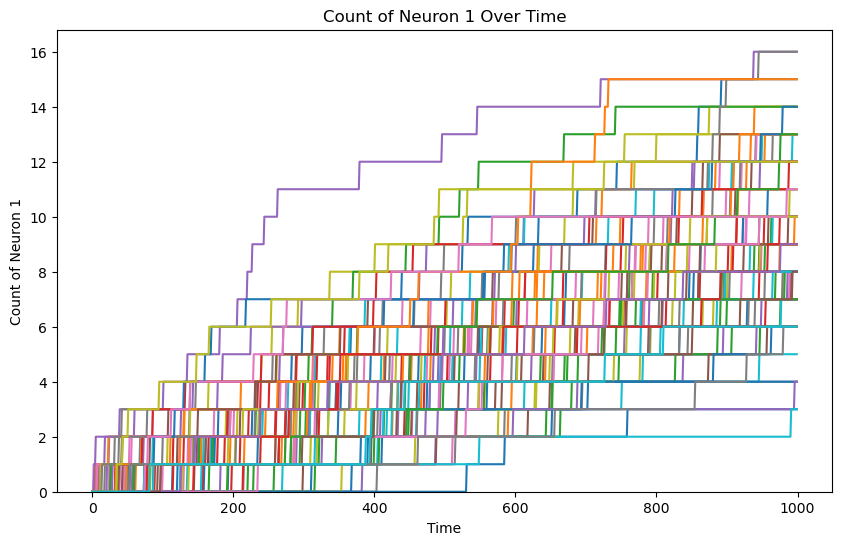

In [34]:
plot_count_neuron1_vs_time(count, num_samples)

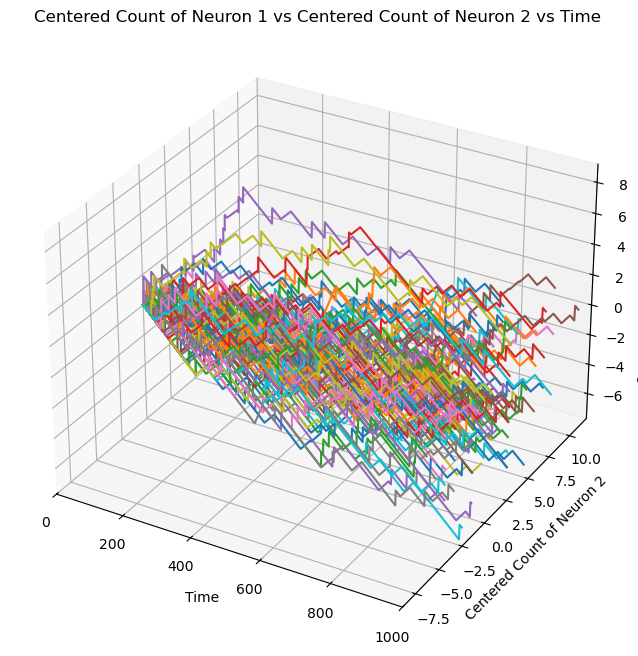

In [35]:
plot_centered_staircase_3d(count, num_samples, theoretical_means, theoretical_std_dev)

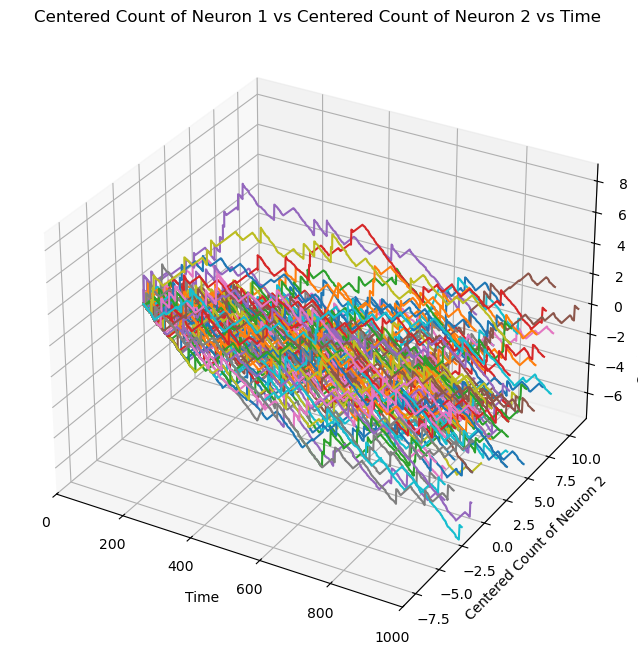

In [36]:
plot_centered_staircase_3d(count, num_samples, empirical_mean, empirical_std_dev)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_28376\3616601278.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_28376\3616601278.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


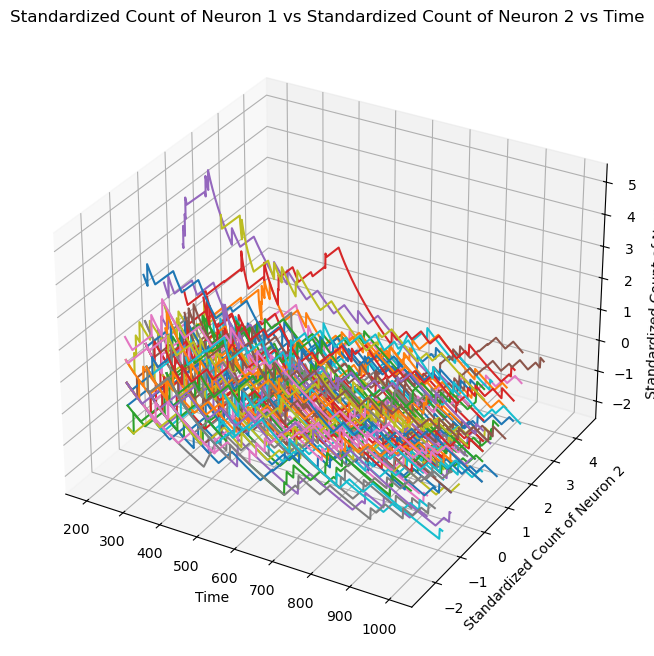

In [37]:
plot_standardized_staircase_3d(count, num_samples, theoretical_means, theoretical_std_dev, t0)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_28376\3616601278.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_28376\3616601278.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


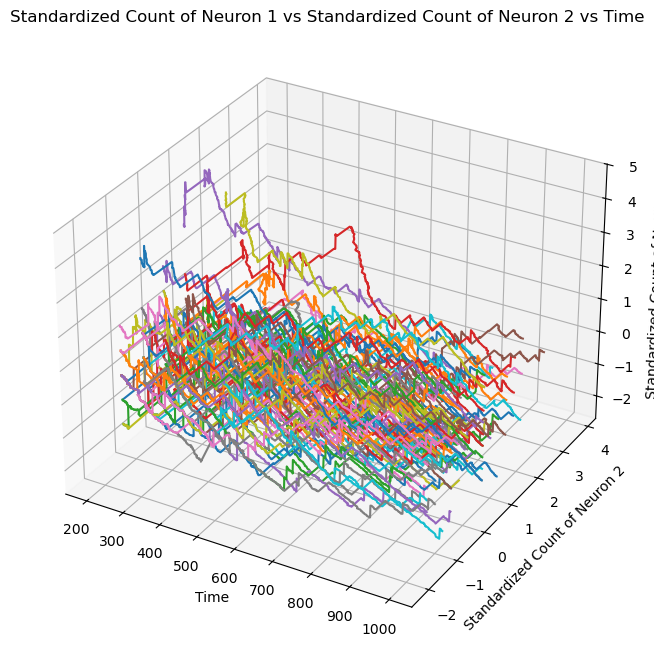

In [38]:
plot_standardized_staircase_3d(count, num_samples, empirical_mean, empirical_std_dev, t0)

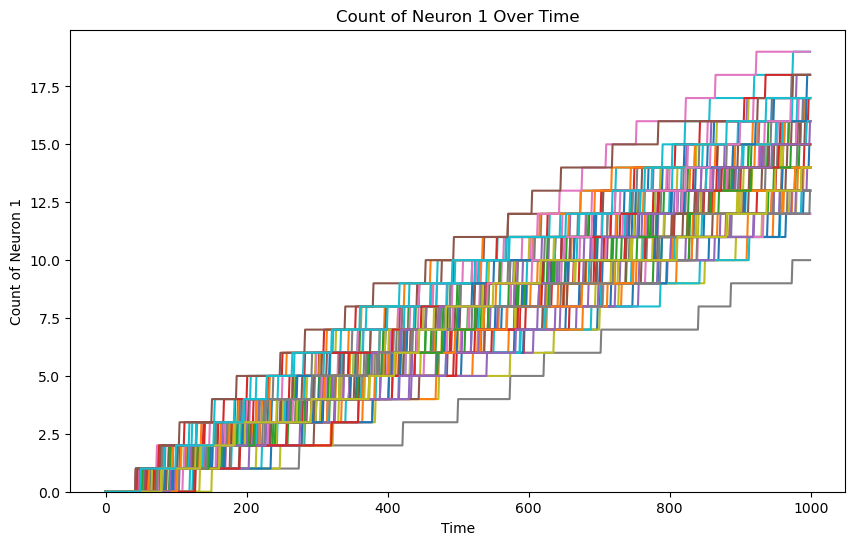

In [39]:
plot_count_neuron1_vs_time(count_ex, num_samples)

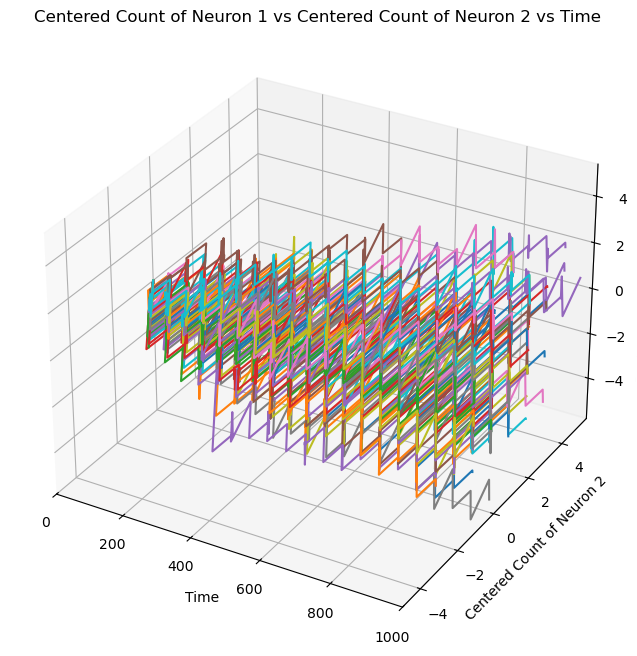

In [40]:
plot_centered_staircase_3d(count_ex, num_samples, theoretical_means_sim_ex, theoretical_std_dev_sim_ex)

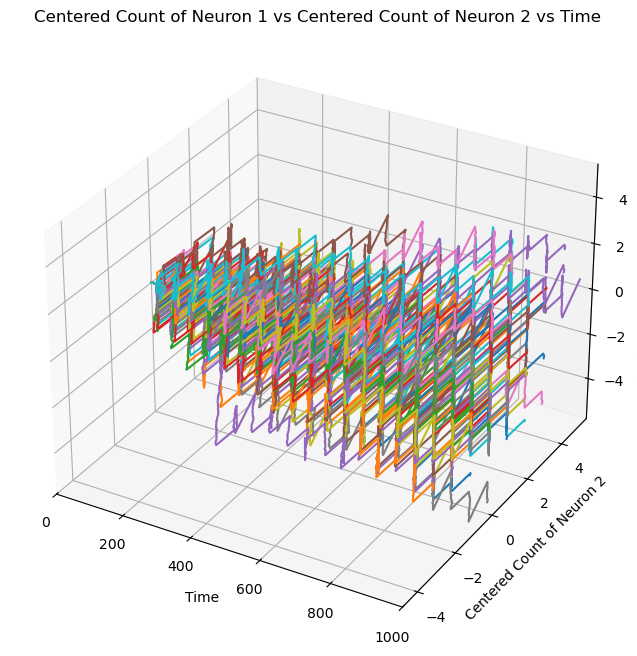

In [41]:
plot_centered_staircase_3d(count_ex, num_samples, empirical_mean_ex, empirical_std_dev_ex)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_28376\3616601278.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_28376\3616601278.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


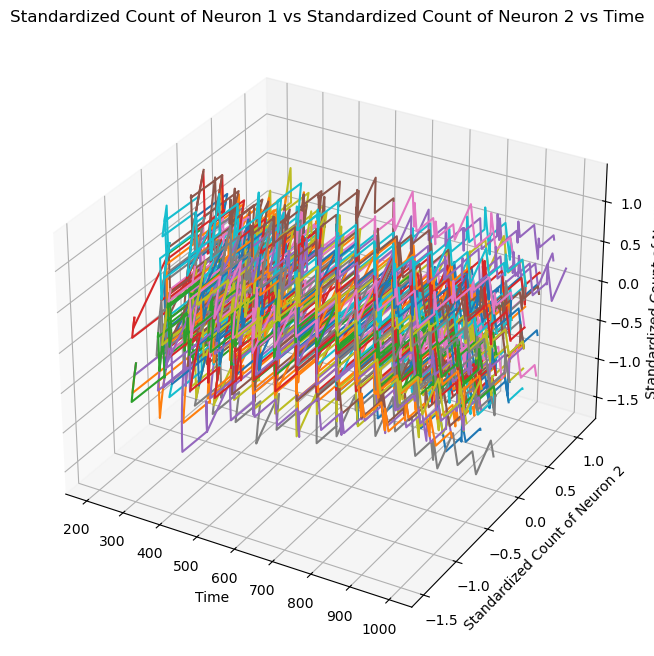

In [42]:
plot_standardized_staircase_3d(count_ex, num_samples, theoretical_means_sim_ex, theoretical_std_dev_sim_ex, t0)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_28376\3616601278.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_28376\3616601278.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


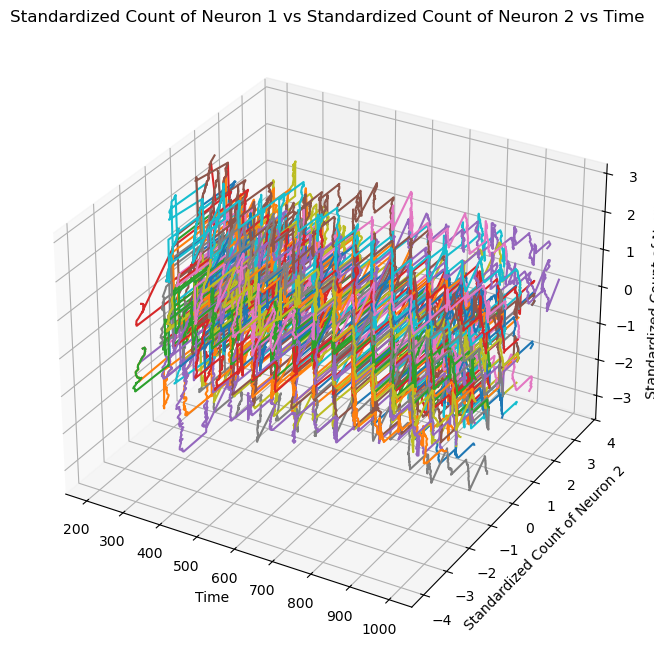

In [43]:
plot_standardized_staircase_3d(count_ex, num_samples, empirical_mean_ex, empirical_std_dev_ex, t0)

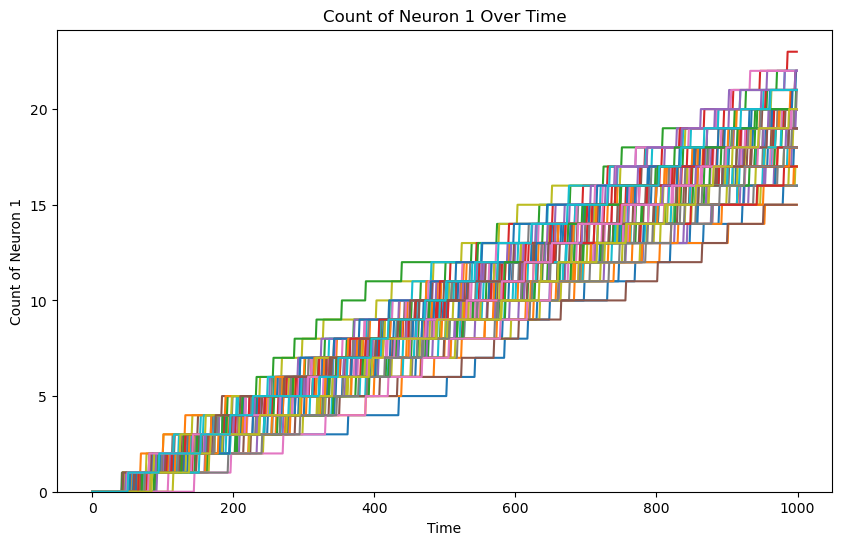

In [44]:
plot_count_neuron1_vs_time(count_in, num_samples)

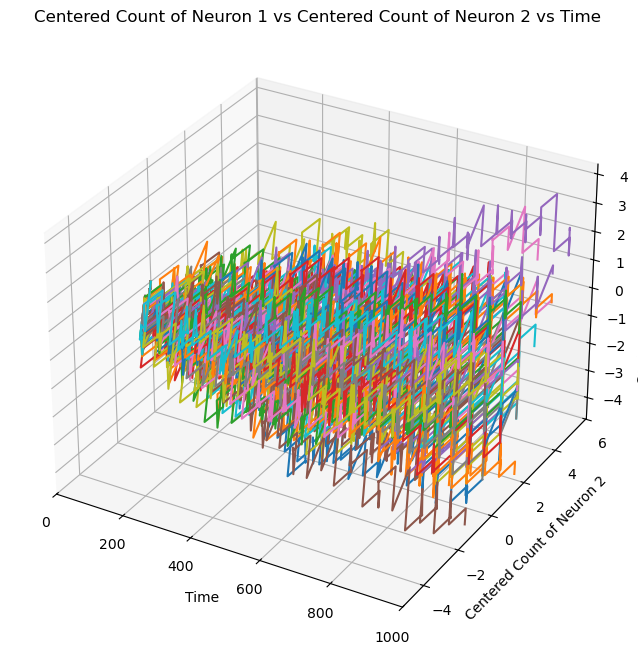

In [45]:
plot_centered_staircase_3d(count_in, num_samples, theoretical_means_sim_in, theoretical_std_dev_sim_in)

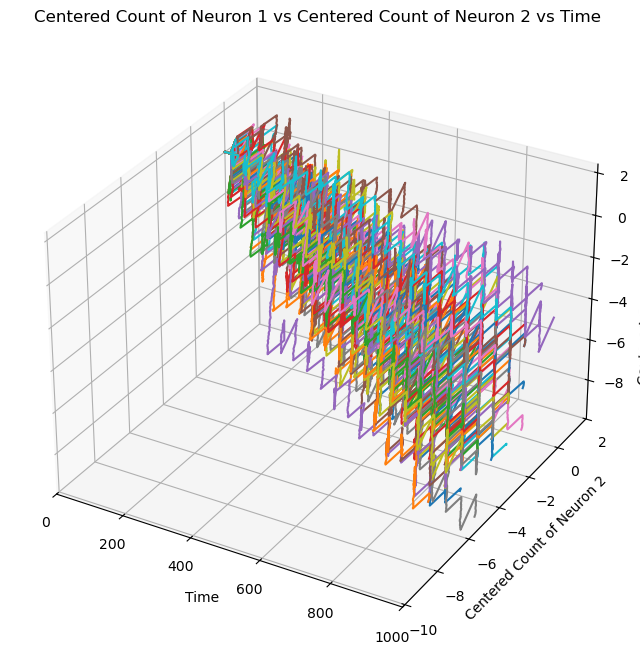

In [46]:
plot_centered_staircase_3d(count_ex, num_samples, empirical_mean_in, empirical_std_dev_in)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_28376\3616601278.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_28376\3616601278.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


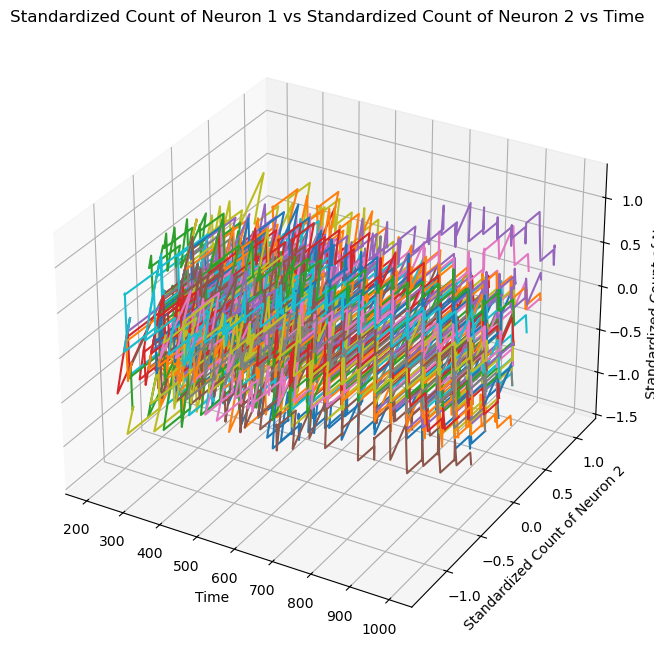

In [47]:
plot_standardized_staircase_3d(count_in, num_samples, theoretical_means_sim_in, theoretical_std_dev_sim_in, t0)

WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_28376\3616601278.py:8: RuntimeWarning: invalid value encountered in divide
  neuron1_data = (count[i][0] - theoretical_means[0]) / (theoretical_std_dev[0])
 [py.warnings]
WARNING    C:\Users\agreg\AppData\Local\Temp\ipykernel_28376\3616601278.py:9: RuntimeWarning: invalid value encountered in divide
  neuron2_data = (count[i][1] - theoretical_means[1]) / (theoretical_std_dev[1])
 [py.warnings]


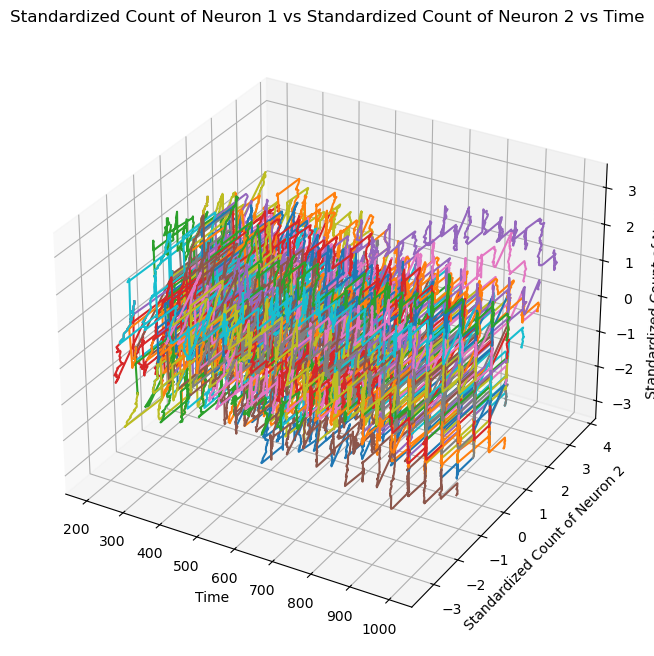

In [48]:
plot_standardized_staircase_3d(count_in, num_samples, empirical_mean_in, empirical_std_dev_in, t0)

In [49]:
# plot_standardized_staircase_3d(count_in, num_samples, theoretical_means_sim, theoretical_std_dev_sim, t0)